<a href="https://colab.research.google.com/github/lmf55/RNA-e-Deep-Learning---CESAR-School-2025.02/blob/main/Atividade%20Aula%203.2/Atividade_Aula_3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão Softmax com dados do MNIST

## Objetivo

O objetivo deste notebook é ilustrar o uso de praticamente a mesma rede desenvolvida para a classificação das flores Íris, porém agora com o problema de classificação de dígitos manuscritos utilizando o dataset MNIST.
As principais diferenças são:
- tipo do dado, agora imagem com muito atributos: 28 x 28 pixels
- número de amostras, muito maior, 60 mil
Neste exercício será possível a interpretação do significado dos parâmetros treinados

## Importação das bibliotecas

In [24]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable

import torchvision

## Carregamento dos dados do MNIST

In [25]:
! git clone https://github.com/vcasadei/MNIST.git

fatal: destination path 'MNIST' already exists and is not an empty directory.


In [26]:
!ls MNIST

processed  raw


In [27]:
dataset_dir = 'MNIST/'

x_train, y_train = torch.load(dataset_dir + 'processed/training.pt')

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 60000

Dimensões dos dados das imagens:    torch.Size([60000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento, normalização e seleção dos dados do MNIST

Neste exemplo utilizaremos apenas 1000 amostras de treinamento.

In [28]:
x_train = x_train.float()

x_train = x_train / 255.

if True:
    n_samples_train = 1000

    x_train = x_train[:n_samples_train]
    y_train = y_train[:n_samples_train]

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 1000

Dimensões dos dados das imagens:    torch.Size([1000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0.) tensor(1.)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento e normalização dos dados de validação

In [29]:
x_val, y_val = torch.load(dataset_dir + 'processed/test.pt')

x_val = x_val.float()
x_val = x_val / 255.

# Limit validation samples for consistency with training set, if needed
# If you want to use the full test set for validation, comment this block
if True:
    n_samples_val = 200 # Using a smaller validation set for demonstration

    x_val = x_val[:n_samples_val]
    y_val = y_val[:n_samples_val]

print("Amostras de validação:", x_val.size(0))

print("\nDimensões dos dados das imagens de validação:   ", x_val.size())
print("Valores mínimo e máximo dos pixels de validação:", torch.min(x_val), torch.max(x_val))
print("Tipo dos dados das imagens de validação:        ", type(x_val))
print("Tipo das classes das imagens de validação:      ", type(y_val))

Amostras de validação: 200

Dimensões dos dados das imagens de validação:    torch.Size([200, 28, 28])
Valores mínimo e máximo dos pixels de validação: tensor(0.) tensor(1.)
Tipo dos dados das imagens de validação:         <class 'torch.Tensor'>
Tipo das classes das imagens de validação:       <class 'torch.Tensor'>


### Visualizando os dados

(np.float64(-0.5), np.float64(232.5), np.float64(87.5), np.float64(-0.5))

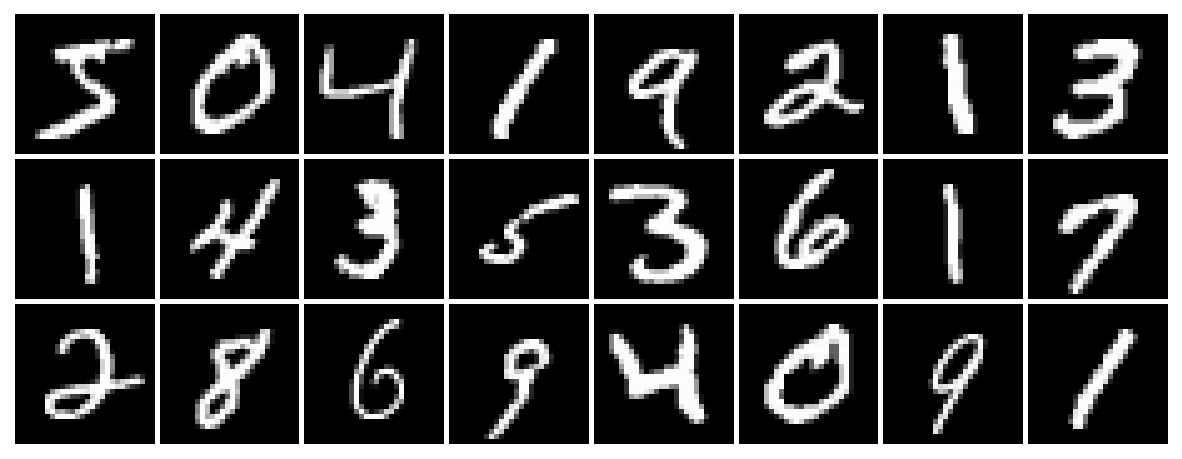

In [30]:
n_samples = 24

# cria um grid com as imagens
grid = torchvision.utils.make_grid(x_train[:n_samples].unsqueeze(dim=1), pad_value=1.0, padding=1)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off')

### Visualizando uma imagem com o matplotlib

class: tensor(5)


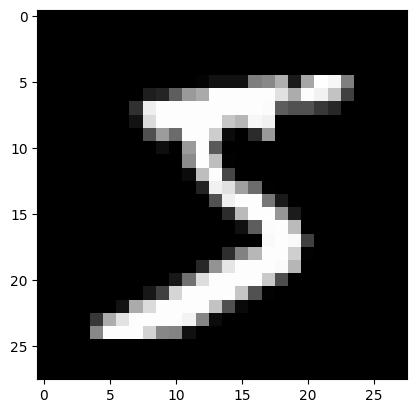

In [31]:
image  = x_train[0]
target = y_train[0]

plt.imshow(image.numpy(), cmap='gray')
print('class:', target)

## Modelo

In [32]:
model = torch.nn.Linear(28*28, 10) # 28*28 atributos de entrada e 10 neurônios na sáida

### Testando um predict com poucas amostras

In [33]:
xin = x_train[:5].view(-1,28*28)
score = model(Variable(xin))
score

tensor([[-0.1697,  0.0517, -0.2468,  0.0457,  0.0457,  0.2086, -0.0810,  0.2604,
         -0.0257,  0.0471],
        [-0.2845,  0.3682, -0.2503, -0.2381,  0.0921,  0.1373,  0.1589,  0.1302,
         -0.0745, -0.0805],
        [-0.1835, -0.0679, -0.1530,  0.0028,  0.1723, -0.0143,  0.1441,  0.1001,
         -0.3058,  0.1913],
        [-0.2354,  0.1427, -0.1740, -0.2023,  0.3288,  0.1101, -0.0032, -0.1460,
         -0.0169,  0.0998],
        [-0.0275, -0.2386,  0.1582, -0.1843,  0.0566, -0.1361,  0.1360, -0.0124,
          0.1374,  0.0619]], grad_fn=<AddmmBackward0>)

## Treinamento

### Inicialização dos parâmetros

In [34]:
epochs = 100
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos pesos

In [35]:
import numpy
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()


### Laço de treinamento dos pesos (com validação e armazenamento de métricas)

Epoch [1/100], Train Loss: 2.274987, Train Acc: 0.109000, Val Loss: 1.857301, Val Acc: 0.590000


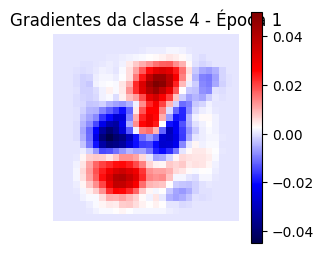

Epoch [2/100], Train Loss: 1.777617, Train Acc: 0.665000, Val Loss: 1.548892, Val Acc: 0.715000


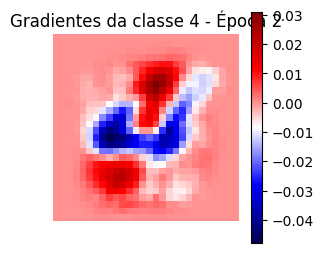

Epoch [3/100], Train Loss: 1.447776, Train Acc: 0.777000, Val Loss: 1.359448, Val Acc: 0.720000


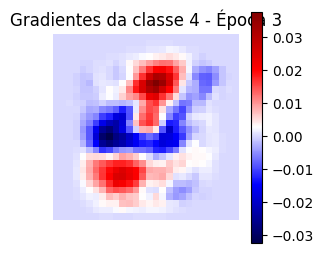

Epoch [4/100], Train Loss: 1.231921, Train Acc: 0.779000, Val Loss: 1.217104, Val Acc: 0.730000


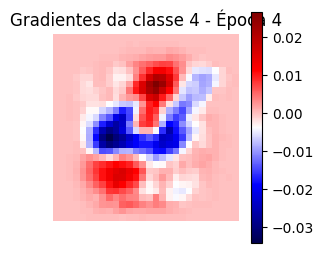

Epoch [5/100], Train Loss: 1.084740, Train Acc: 0.812000, Val Loss: 1.119402, Val Acc: 0.760000


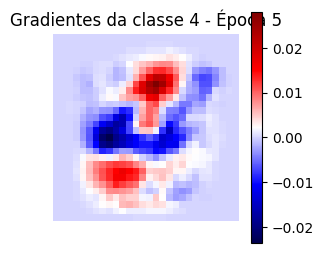

Epoch [6/100], Train Loss: 0.979712, Train Acc: 0.818000, Val Loss: 1.041929, Val Acc: 0.760000


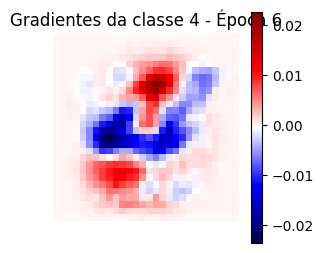

Epoch [7/100], Train Loss: 0.901181, Train Acc: 0.833000, Val Loss: 0.982417, Val Acc: 0.760000


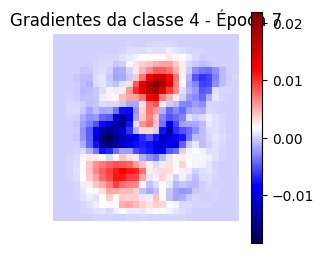

Epoch [8/100], Train Loss: 0.840056, Train Acc: 0.838000, Val Loss: 0.932709, Val Acc: 0.775000


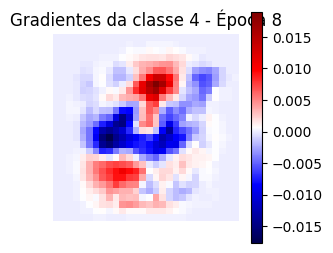

Epoch [9/100], Train Loss: 0.790898, Train Acc: 0.848000, Val Loss: 0.892057, Val Acc: 0.770000


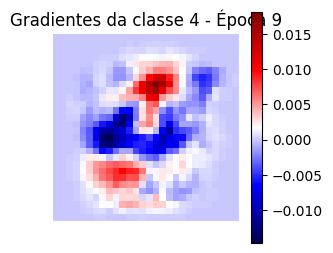

Epoch [10/100], Train Loss: 0.750327, Train Acc: 0.853000, Val Loss: 0.856830, Val Acc: 0.780000


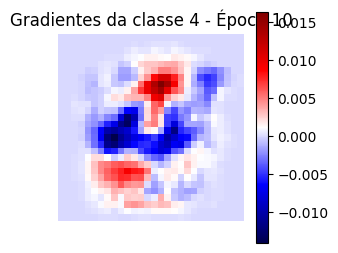

Epoch [11/100], Train Loss: 0.716128, Train Acc: 0.862000, Val Loss: 0.826730, Val Acc: 0.785000


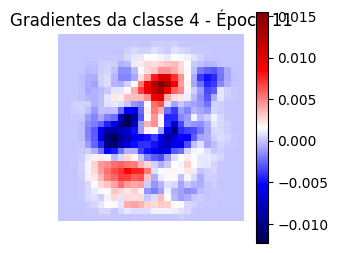

Epoch [12/100], Train Loss: 0.686796, Train Acc: 0.863000, Val Loss: 0.800100, Val Acc: 0.785000


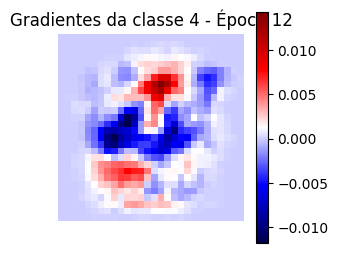

Epoch [13/100], Train Loss: 0.661272, Train Acc: 0.867000, Val Loss: 0.776612, Val Acc: 0.790000


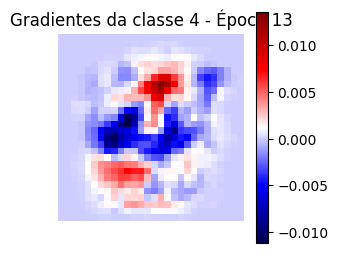

Epoch [14/100], Train Loss: 0.638791, Train Acc: 0.871000, Val Loss: 0.755519, Val Acc: 0.800000


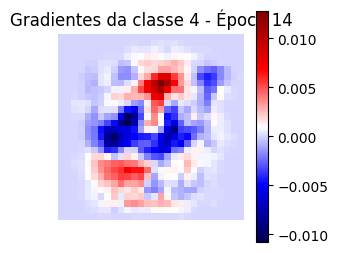

Epoch [15/100], Train Loss: 0.618787, Train Acc: 0.872000, Val Loss: 0.736515, Val Acc: 0.810000


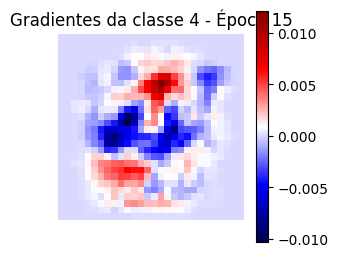

Epoch [16/100], Train Loss: 0.600829, Train Acc: 0.874000, Val Loss: 0.719230, Val Acc: 0.810000


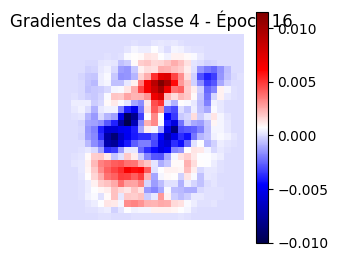

Epoch [17/100], Train Loss: 0.584584, Train Acc: 0.877000, Val Loss: 0.703432, Val Acc: 0.815000


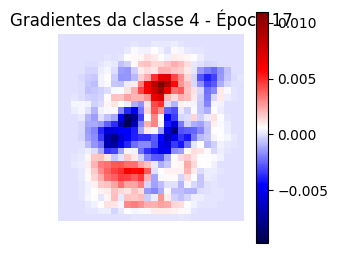

Epoch [18/100], Train Loss: 0.569789, Train Acc: 0.878000, Val Loss: 0.688908, Val Acc: 0.820000


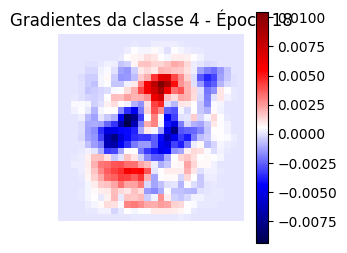

Epoch [19/100], Train Loss: 0.556234, Train Acc: 0.883000, Val Loss: 0.675494, Val Acc: 0.825000


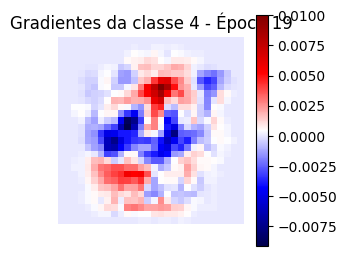

Epoch [20/100], Train Loss: 0.543751, Train Acc: 0.883000, Val Loss: 0.663053, Val Acc: 0.830000


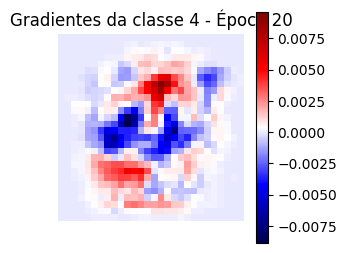

Epoch [21/100], Train Loss: 0.532199, Train Acc: 0.884000, Val Loss: 0.651471, Val Acc: 0.835000


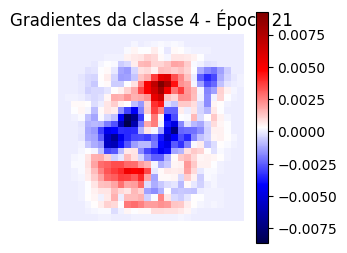

Epoch [22/100], Train Loss: 0.521464, Train Acc: 0.887000, Val Loss: 0.640652, Val Acc: 0.840000


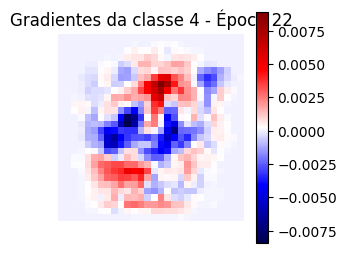

Epoch [23/100], Train Loss: 0.511450, Train Acc: 0.887000, Val Loss: 0.630515, Val Acc: 0.850000


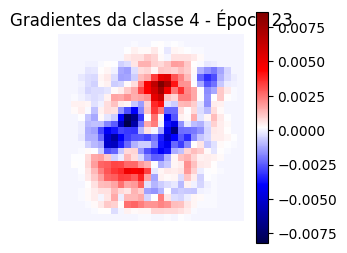

Epoch [24/100], Train Loss: 0.502075, Train Acc: 0.888000, Val Loss: 0.620991, Val Acc: 0.850000


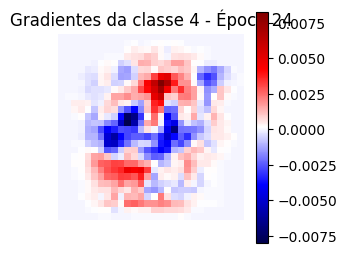

Epoch [25/100], Train Loss: 0.493272, Train Acc: 0.888000, Val Loss: 0.612019, Val Acc: 0.850000


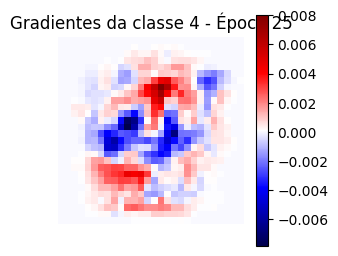

Epoch [26/100], Train Loss: 0.484980, Train Acc: 0.890000, Val Loss: 0.603549, Val Acc: 0.850000


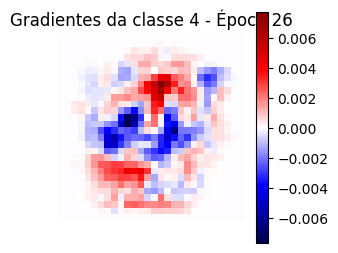

Epoch [27/100], Train Loss: 0.477150, Train Acc: 0.892000, Val Loss: 0.595535, Val Acc: 0.850000


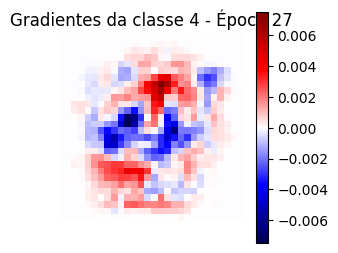

Epoch [28/100], Train Loss: 0.469738, Train Acc: 0.895000, Val Loss: 0.587938, Val Acc: 0.855000


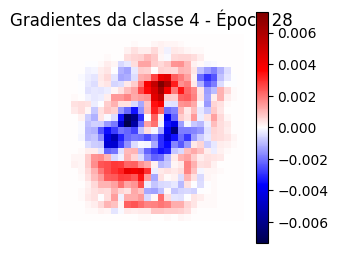

Epoch [29/100], Train Loss: 0.462705, Train Acc: 0.896000, Val Loss: 0.580724, Val Acc: 0.855000


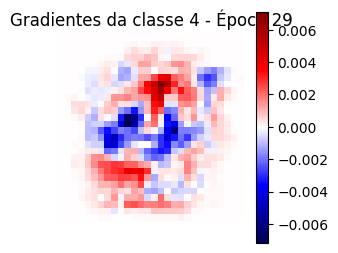

Epoch [30/100], Train Loss: 0.456018, Train Acc: 0.899000, Val Loss: 0.573862, Val Acc: 0.855000


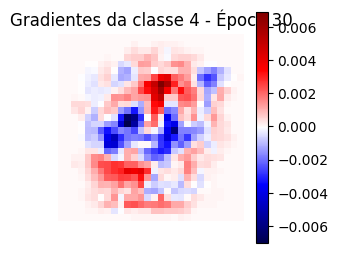

Epoch [31/100], Train Loss: 0.449648, Train Acc: 0.900000, Val Loss: 0.567324, Val Acc: 0.855000


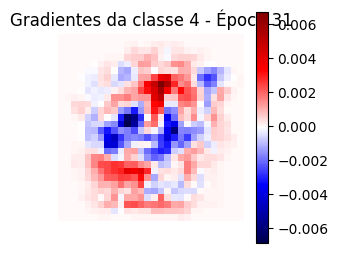

Epoch [32/100], Train Loss: 0.443568, Train Acc: 0.901000, Val Loss: 0.561087, Val Acc: 0.860000


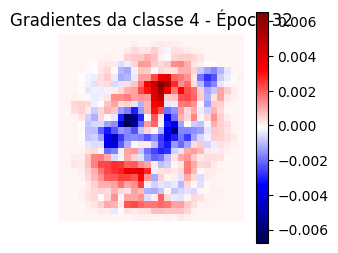

Epoch [33/100], Train Loss: 0.437755, Train Acc: 0.901000, Val Loss: 0.555127, Val Acc: 0.865000


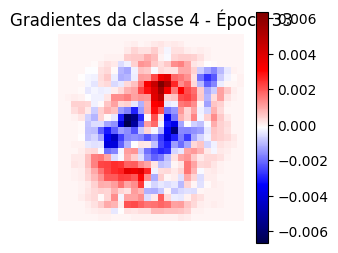

Epoch [34/100], Train Loss: 0.432189, Train Acc: 0.902000, Val Loss: 0.549427, Val Acc: 0.870000


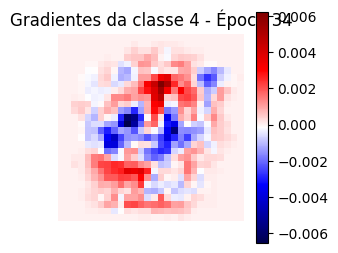

Epoch [35/100], Train Loss: 0.426851, Train Acc: 0.902000, Val Loss: 0.543968, Val Acc: 0.870000


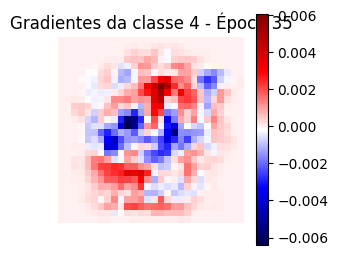

Epoch [36/100], Train Loss: 0.421725, Train Acc: 0.905000, Val Loss: 0.538735, Val Acc: 0.870000


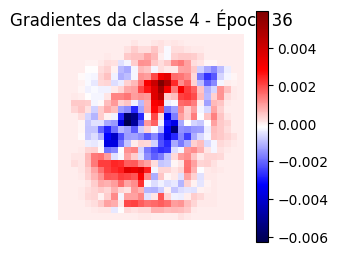

Epoch [37/100], Train Loss: 0.416796, Train Acc: 0.905000, Val Loss: 0.533712, Val Acc: 0.870000


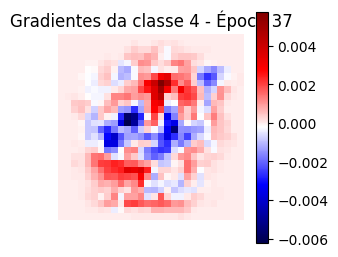

Epoch [38/100], Train Loss: 0.412051, Train Acc: 0.908000, Val Loss: 0.528887, Val Acc: 0.880000


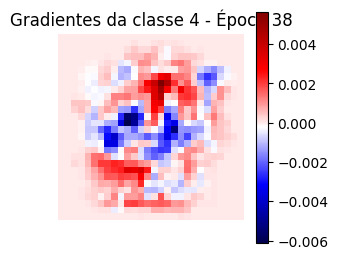

Epoch [39/100], Train Loss: 0.407477, Train Acc: 0.908000, Val Loss: 0.524247, Val Acc: 0.885000


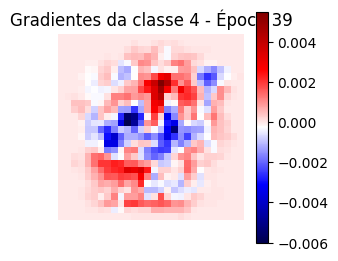

Epoch [40/100], Train Loss: 0.403062, Train Acc: 0.911000, Val Loss: 0.519782, Val Acc: 0.885000


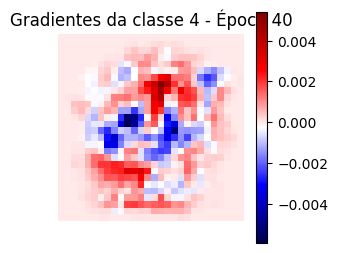

Epoch [41/100], Train Loss: 0.398798, Train Acc: 0.911000, Val Loss: 0.515481, Val Acc: 0.885000


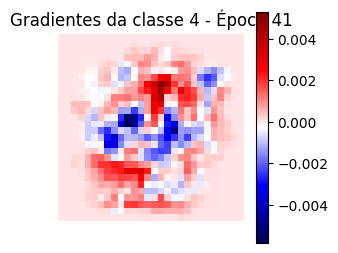

Epoch [42/100], Train Loss: 0.394675, Train Acc: 0.913000, Val Loss: 0.511335, Val Acc: 0.885000


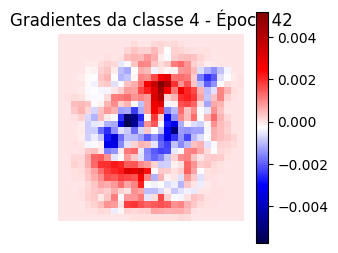

Epoch [43/100], Train Loss: 0.390685, Train Acc: 0.913000, Val Loss: 0.507335, Val Acc: 0.885000


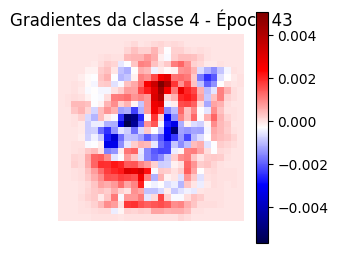

Epoch [44/100], Train Loss: 0.386819, Train Acc: 0.914000, Val Loss: 0.503475, Val Acc: 0.885000


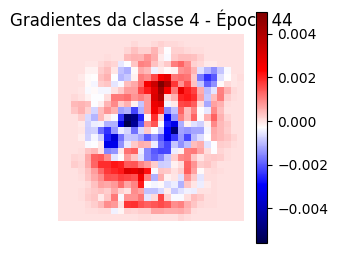

Epoch [45/100], Train Loss: 0.383072, Train Acc: 0.915000, Val Loss: 0.499745, Val Acc: 0.885000


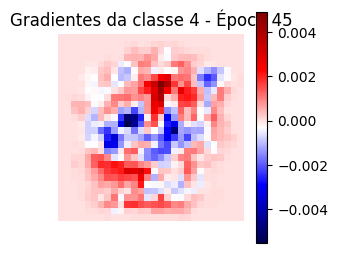

Epoch [46/100], Train Loss: 0.379435, Train Acc: 0.917000, Val Loss: 0.496140, Val Acc: 0.885000


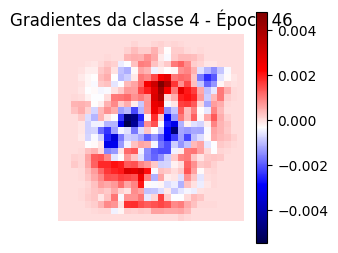

Epoch [47/100], Train Loss: 0.375904, Train Acc: 0.918000, Val Loss: 0.492653, Val Acc: 0.890000


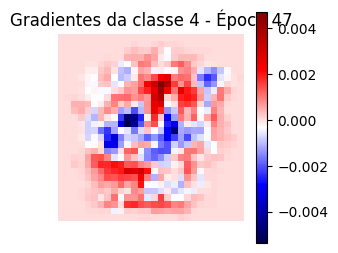

Epoch [48/100], Train Loss: 0.372472, Train Acc: 0.918000, Val Loss: 0.489278, Val Acc: 0.895000


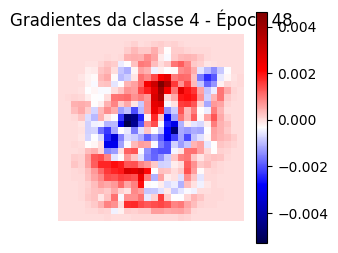

Epoch [49/100], Train Loss: 0.369134, Train Acc: 0.920000, Val Loss: 0.486010, Val Acc: 0.895000


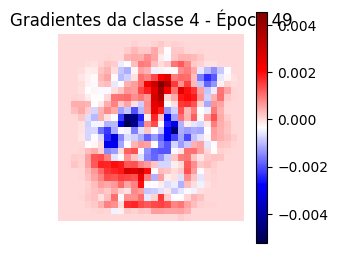

Epoch [50/100], Train Loss: 0.365887, Train Acc: 0.920000, Val Loss: 0.482843, Val Acc: 0.895000


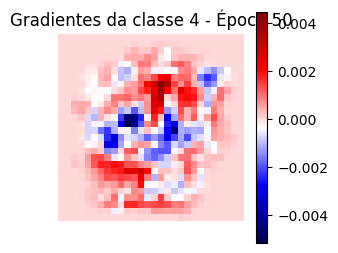

Epoch [51/100], Train Loss: 0.362725, Train Acc: 0.922000, Val Loss: 0.479774, Val Acc: 0.900000


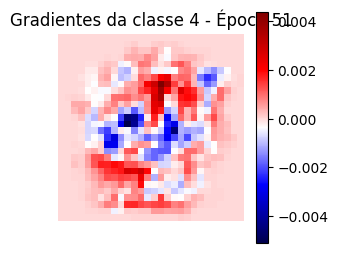

Epoch [52/100], Train Loss: 0.359643, Train Acc: 0.922000, Val Loss: 0.476797, Val Acc: 0.900000


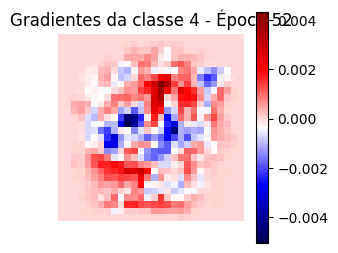

Epoch [53/100], Train Loss: 0.356640, Train Acc: 0.922000, Val Loss: 0.473908, Val Acc: 0.900000


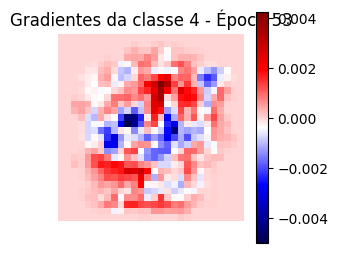

Epoch [54/100], Train Loss: 0.353709, Train Acc: 0.922000, Val Loss: 0.471104, Val Acc: 0.900000


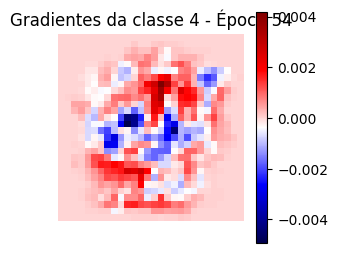

Epoch [55/100], Train Loss: 0.350849, Train Acc: 0.923000, Val Loss: 0.468381, Val Acc: 0.900000


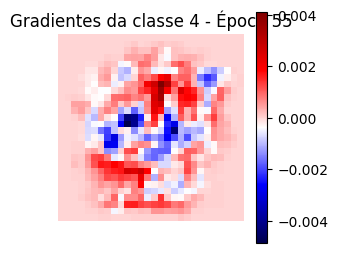

Epoch [56/100], Train Loss: 0.348057, Train Acc: 0.923000, Val Loss: 0.465735, Val Acc: 0.905000


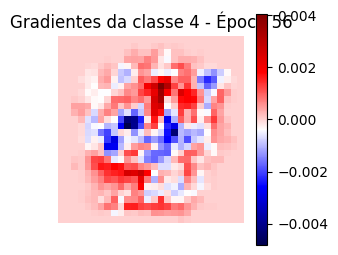

Epoch [57/100], Train Loss: 0.345329, Train Acc: 0.923000, Val Loss: 0.463163, Val Acc: 0.905000


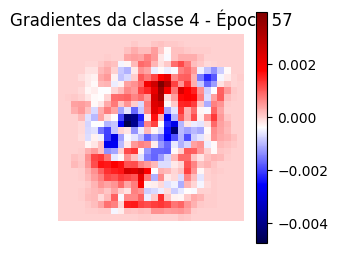

Epoch [58/100], Train Loss: 0.342662, Train Acc: 0.925000, Val Loss: 0.460662, Val Acc: 0.905000


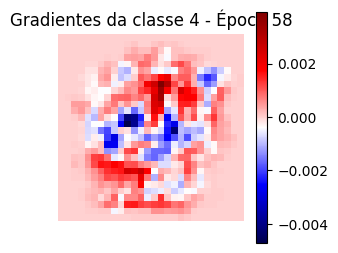

Epoch [59/100], Train Loss: 0.340054, Train Acc: 0.925000, Val Loss: 0.458229, Val Acc: 0.905000


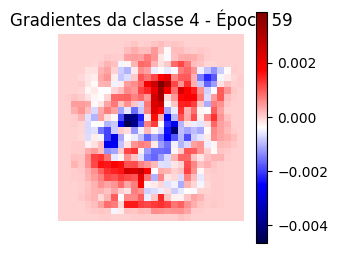

Epoch [60/100], Train Loss: 0.337502, Train Acc: 0.926000, Val Loss: 0.455861, Val Acc: 0.905000


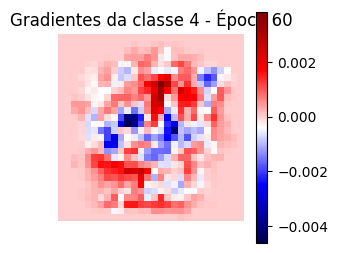

Epoch [61/100], Train Loss: 0.335005, Train Acc: 0.926000, Val Loss: 0.453556, Val Acc: 0.905000


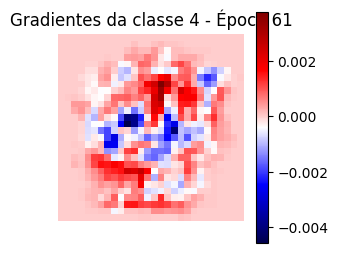

Epoch [62/100], Train Loss: 0.332560, Train Acc: 0.927000, Val Loss: 0.451312, Val Acc: 0.905000


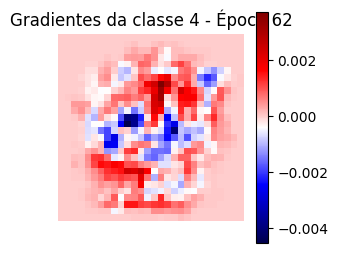

Epoch [63/100], Train Loss: 0.330165, Train Acc: 0.927000, Val Loss: 0.449125, Val Acc: 0.905000


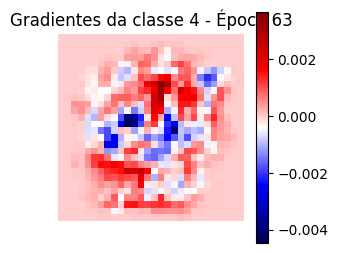

Epoch [64/100], Train Loss: 0.327818, Train Acc: 0.928000, Val Loss: 0.446995, Val Acc: 0.905000


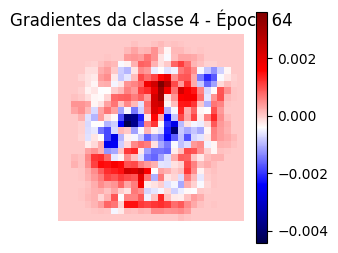

Epoch [65/100], Train Loss: 0.325517, Train Acc: 0.928000, Val Loss: 0.444918, Val Acc: 0.905000


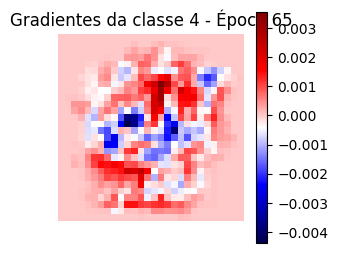

Epoch [66/100], Train Loss: 0.323261, Train Acc: 0.929000, Val Loss: 0.442893, Val Acc: 0.905000


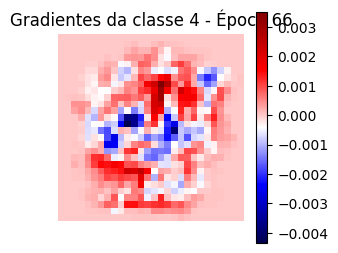

Epoch [67/100], Train Loss: 0.321048, Train Acc: 0.929000, Val Loss: 0.440918, Val Acc: 0.905000


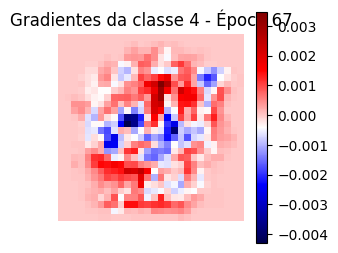

Epoch [68/100], Train Loss: 0.318876, Train Acc: 0.930000, Val Loss: 0.438992, Val Acc: 0.905000


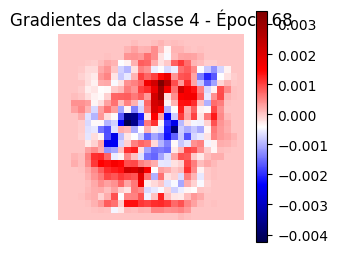

Epoch [69/100], Train Loss: 0.316744, Train Acc: 0.931000, Val Loss: 0.437111, Val Acc: 0.905000


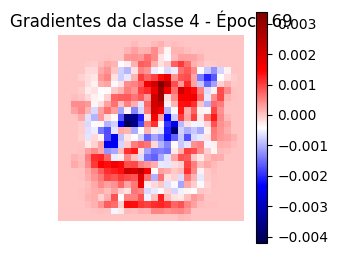

Epoch [70/100], Train Loss: 0.314651, Train Acc: 0.931000, Val Loss: 0.435276, Val Acc: 0.905000


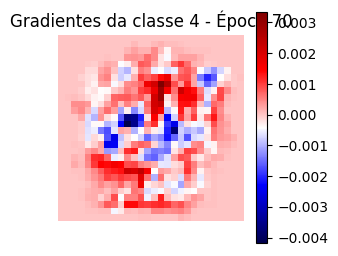

Epoch [71/100], Train Loss: 0.312595, Train Acc: 0.932000, Val Loss: 0.433484, Val Acc: 0.905000


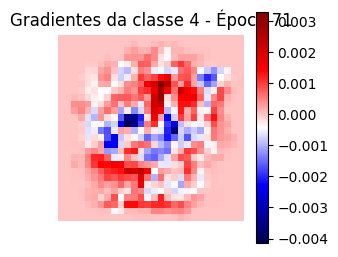

Epoch [72/100], Train Loss: 0.310575, Train Acc: 0.932000, Val Loss: 0.431734, Val Acc: 0.905000


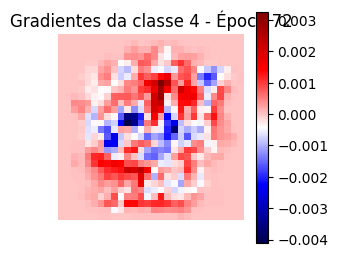

Epoch [73/100], Train Loss: 0.308589, Train Acc: 0.933000, Val Loss: 0.430024, Val Acc: 0.905000


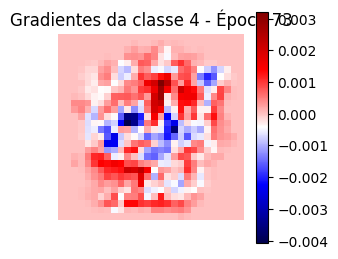

Epoch [74/100], Train Loss: 0.306638, Train Acc: 0.934000, Val Loss: 0.428353, Val Acc: 0.905000


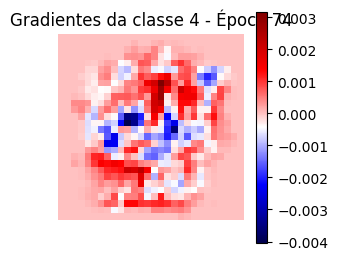

Epoch [75/100], Train Loss: 0.304719, Train Acc: 0.936000, Val Loss: 0.426720, Val Acc: 0.905000


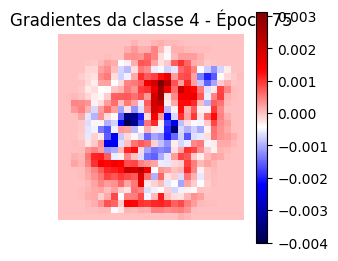

Epoch [76/100], Train Loss: 0.302831, Train Acc: 0.936000, Val Loss: 0.425124, Val Acc: 0.905000


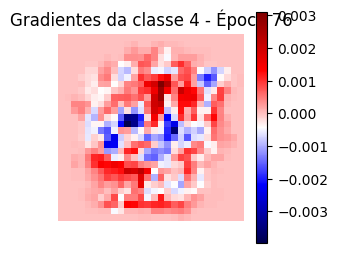

Epoch [77/100], Train Loss: 0.300974, Train Acc: 0.936000, Val Loss: 0.423564, Val Acc: 0.905000


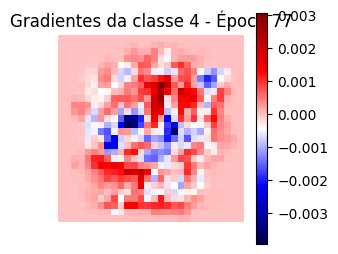

Epoch [78/100], Train Loss: 0.299147, Train Acc: 0.936000, Val Loss: 0.422038, Val Acc: 0.905000


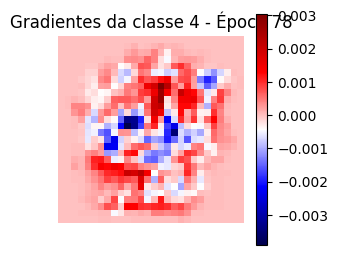

Epoch [79/100], Train Loss: 0.297349, Train Acc: 0.936000, Val Loss: 0.420544, Val Acc: 0.905000


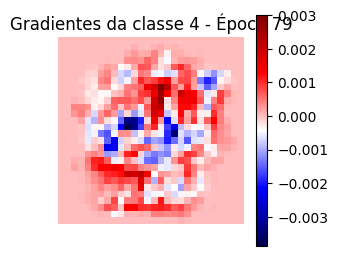

Epoch [80/100], Train Loss: 0.295578, Train Acc: 0.937000, Val Loss: 0.419084, Val Acc: 0.905000


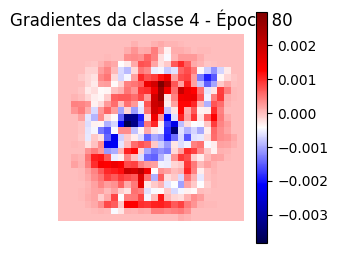

Epoch [81/100], Train Loss: 0.293835, Train Acc: 0.937000, Val Loss: 0.417654, Val Acc: 0.905000


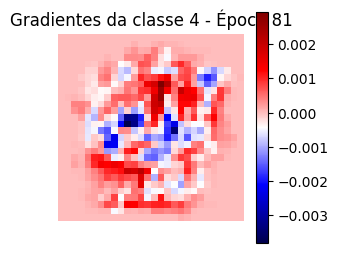

Epoch [82/100], Train Loss: 0.292118, Train Acc: 0.937000, Val Loss: 0.416255, Val Acc: 0.905000


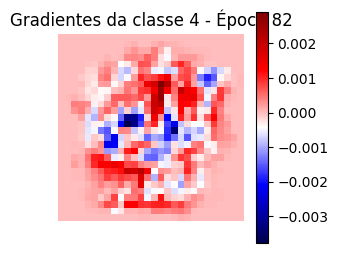

Epoch [83/100], Train Loss: 0.290426, Train Acc: 0.938000, Val Loss: 0.414886, Val Acc: 0.905000


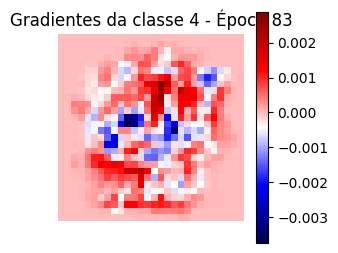

Epoch [84/100], Train Loss: 0.288759, Train Acc: 0.938000, Val Loss: 0.413545, Val Acc: 0.905000


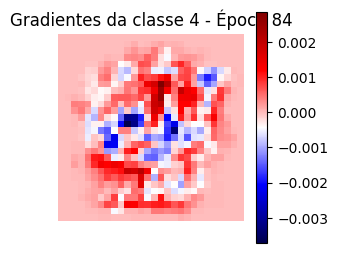

Epoch [85/100], Train Loss: 0.287117, Train Acc: 0.938000, Val Loss: 0.412231, Val Acc: 0.905000


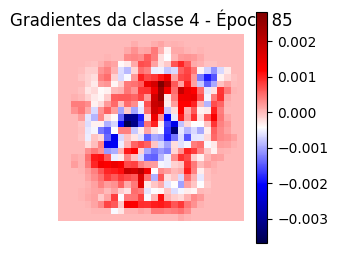

Epoch [86/100], Train Loss: 0.285498, Train Acc: 0.938000, Val Loss: 0.410945, Val Acc: 0.905000


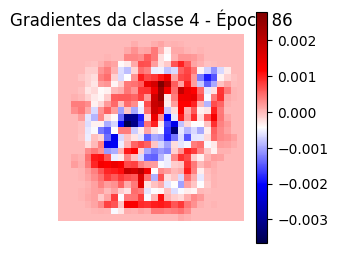

Epoch [87/100], Train Loss: 0.283901, Train Acc: 0.939000, Val Loss: 0.409685, Val Acc: 0.905000


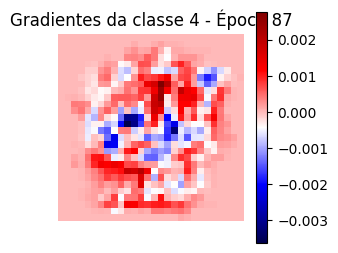

Epoch [88/100], Train Loss: 0.282327, Train Acc: 0.939000, Val Loss: 0.408450, Val Acc: 0.905000


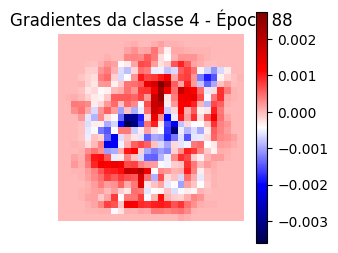

Epoch [89/100], Train Loss: 0.280775, Train Acc: 0.940000, Val Loss: 0.407240, Val Acc: 0.905000


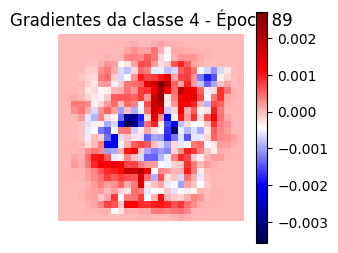

Epoch [90/100], Train Loss: 0.279244, Train Acc: 0.940000, Val Loss: 0.406054, Val Acc: 0.905000


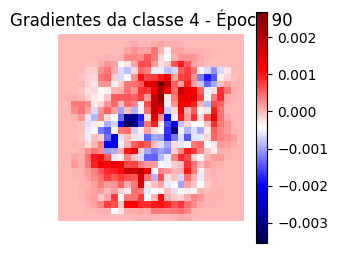

Epoch [91/100], Train Loss: 0.277733, Train Acc: 0.940000, Val Loss: 0.404891, Val Acc: 0.905000


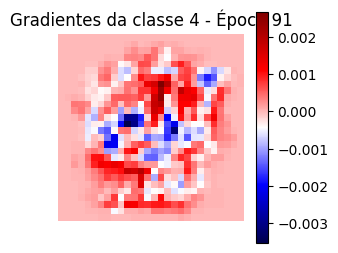

Epoch [92/100], Train Loss: 0.276242, Train Acc: 0.940000, Val Loss: 0.403751, Val Acc: 0.905000


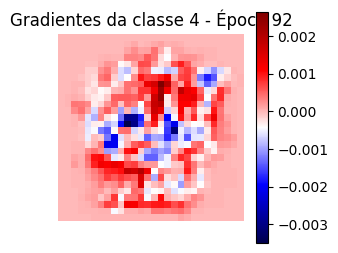

Epoch [93/100], Train Loss: 0.274771, Train Acc: 0.940000, Val Loss: 0.402633, Val Acc: 0.905000


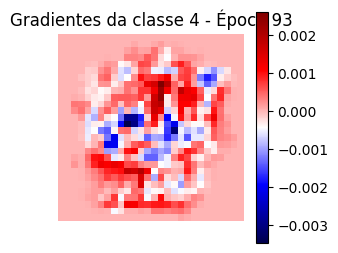

Epoch [94/100], Train Loss: 0.273319, Train Acc: 0.940000, Val Loss: 0.401537, Val Acc: 0.905000


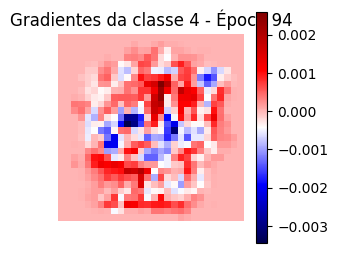

Epoch [95/100], Train Loss: 0.271886, Train Acc: 0.940000, Val Loss: 0.400462, Val Acc: 0.905000


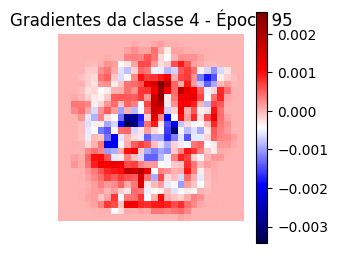

Epoch [96/100], Train Loss: 0.270470, Train Acc: 0.940000, Val Loss: 0.399407, Val Acc: 0.905000


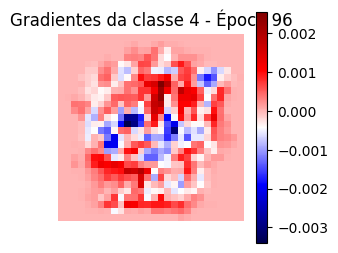

Epoch [97/100], Train Loss: 0.269073, Train Acc: 0.941000, Val Loss: 0.398372, Val Acc: 0.905000


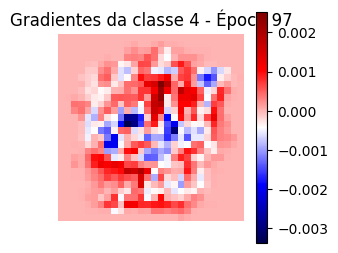

Epoch [98/100], Train Loss: 0.267692, Train Acc: 0.942000, Val Loss: 0.397356, Val Acc: 0.905000


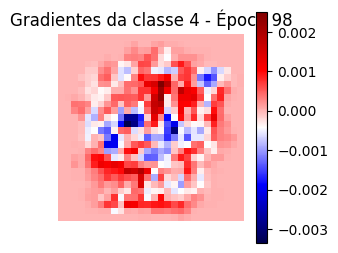

Epoch [99/100], Train Loss: 0.266329, Train Acc: 0.942000, Val Loss: 0.396359, Val Acc: 0.905000


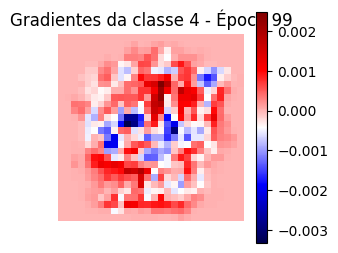

Epoch [100/100], Train Loss: 0.264982, Train Acc: 0.942000, Val Loss: 0.395381, Val Acc: 0.905000


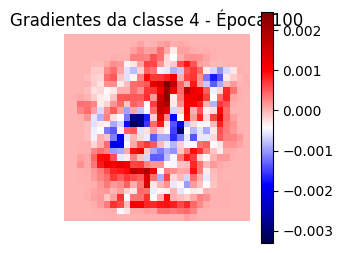

In [36]:
# Recriando o modelo para garantir que o treinamento comece do zero
model = torch.nn.Linear(28*28, 10)

epochs = 100
learningRate = 0.5

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Lista para armazenar os gradientes da classe do dígito 4
grad_digit4_history = []

for i in range(epochs):

    # ---------------------------
    # Treinamento
    # ---------------------------
    model.train()

    # Transforma as imagens 28x28 em vetores com 784 posições
    inputs_train = x_train.view(-1, 28 * 28)

    # Forward: predição da rede
    outputs_train = model(inputs_train)

    # Cálculo da perda
    loss_train = criterion(outputs_train, y_train)

    # Zera gradientes anteriores
    optimizer.zero_grad()

    # Backpropagation: calcula gradientes
    loss_train.backward()

    # Captura os gradientes referentes à classe do dígito 4
    grad_digit4 = model.weight.grad[4, :].detach().clone().view(28, 28)
    grad_digit4_history.append(grad_digit4.numpy())

    # Atualiza os pesos
    optimizer.step()

    # Armazena perda de treino
    train_losses.append(loss_train.item())

    # Calcula acurácia de treino
    _, predicts_train = torch.max(outputs_train, 1)
    accuracy_train = (predicts_train == y_train).float().mean().item()
    train_accuracies.append(accuracy_train)

    # ---------------------------
    # Validação
    # ---------------------------
    model.eval()

    with torch.no_grad():
        inputs_val = x_val.view(-1, 28 * 28)
        outputs_val = model(inputs_val)

        loss_val = criterion(outputs_val, y_val)
        val_losses.append(loss_val.item())

        _, predicts_val = torch.max(outputs_val, 1)
        accuracy_val = (predicts_val == y_val).float().mean().item()
        val_accuracies.append(accuracy_val)

    # ---------------------------
    # Impressão ao final da época
    # ---------------------------
    print(
        'Epoch [{}/{}], Train Loss: {:.6f}, Train Acc: {:.6f}, Val Loss: {:.6f}, Val Acc: {:.6f}'
        .format(
            i + 1,
            epochs,
            loss_train.item(),
            accuracy_train,
            loss_val.item(),
            accuracy_val) )

    # ---------------------------
    # Visualização dos gradientes da classe 4
    # ---------------------------
    plt.figure(figsize=(3, 3))
    plt.imshow(grad_digit4.numpy(), cmap='seismic')
    plt.title(f'Gradientes da classe 4 - Época {i+1}')
    plt.axis('off')
    plt.colorbar()
    plt.show()

In [37]:
print('Final train loss:', train_losses[-1])
print('Final validation loss:', val_losses[-1])
print('Final train accuracy:', train_accuracies[-1])
print('Final validation accuracy:', val_accuracies[-1])

Final train loss: 0.26498210430145264
Final validation loss: 0.3953806757926941
Final train accuracy: 0.9419999718666077
Final validation accuracy: 0.9049999713897705


### Visualizando gráfico de perda durante o treinamento

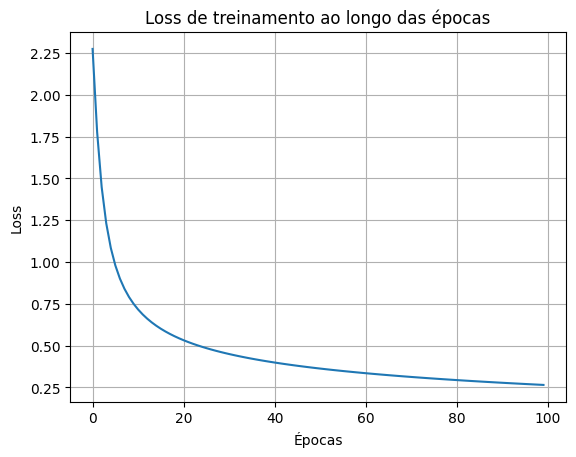

In [38]:
plt.plot(train_losses)
plt.title('Loss de treinamento ao longo das épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

### Visualizando gráficos de perda e acurácia durante o treinamento

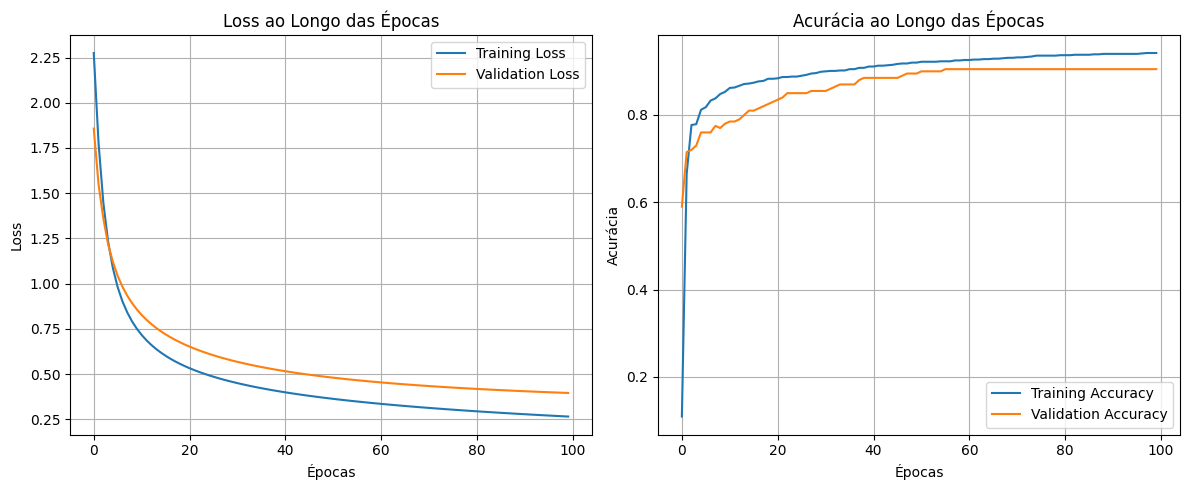

In [39]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acurácia ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Avaliação

### Acurácia tanto no conjunto de treinamento como no conjunto de testes

In [40]:
def predict(model, input_data):
    outputs = model(Variable(input_data))
    _, predicts = torch.max(outputs, 1)

    return predicts.data

y_pred = predict(model, x_train.view(-1, 28*28))
accuracy = (y_pred.numpy() == y_train.numpy()).mean()
print('Accuracy:', accuracy)

Accuracy: 0.942


### Matriz de confusão com dados de treinamento e teste

In [41]:
print('Matriz de confusão:')
pd.crosstab(y_pred.numpy(), y_train.numpy())

Matriz de confusão:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,96,0,1,0,0,0,1,0,0,2
1,0,110,1,0,0,0,2,3,1,0
2,0,1,91,1,0,1,1,1,1,1
3,0,0,0,88,0,2,0,0,0,0
4,0,0,1,0,102,2,0,2,0,3
5,0,2,0,1,0,82,0,0,2,1
6,1,0,1,1,2,2,90,0,0,0
7,0,1,1,1,0,0,0,110,0,3
8,0,2,2,0,0,1,0,0,83,0


## Visualizando a matriz de pesos treinados

Observe que a matriz de peso treinado para cada classe mostra a importância dos pesos associados aos caracteres de cada classe.

weights: torch.Size([10, 784])
bias:    torch.Size([10])


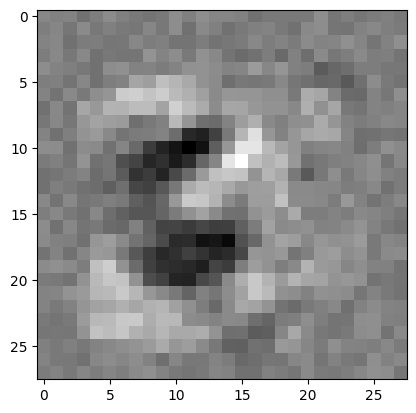

In [42]:
weights = model.state_dict()['weight']
print('weights:', weights.shape)

bias = model.state_dict()['bias']
print('bias:   ', bias.shape)

# Visualizando pesos da classe 3
plt.imshow(weights[3, :].numpy().reshape((28,28)),cmap = 'gray')
plt.show()

### Visualizando os pesos de todas as classes

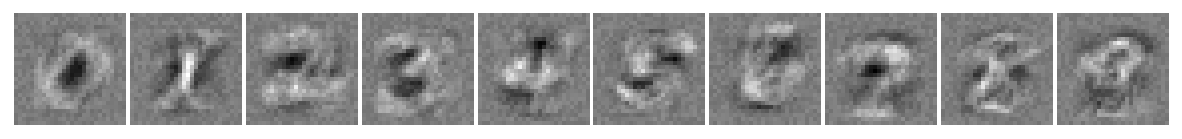

In [43]:
# cria um grid com as imagens
grid = torchvision.utils.make_grid(weights.view(-1, 1, 28, 28), normalize=True, pad_value=1.0, padding=1, nrow=10)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off');

### Diagrama da regressão softmax com visualização dos pesos W

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmaxArgmaxNMIST.png)

# Atividades

## Exercícios

- 1) Insira código no laço do treinamento para que no final de cada época,
     seja impresso: o número da época e a perda e a acurácia

- 2) Insira código no laço do treinamento para visualização dos valores dos gradientes referentes à classe do dígito 4, no final de cada época.

<details>
<summary>Mostrar Resultado</summary>

```python
losses = []
import numpy

import numpy
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)
    
    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    
    _, predicts = torch.max(outputs, 1)
    
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()
    
    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
              .format(i+1, epochs, loss.data, accuracy))
    
    weights = model.state_dict()['weight']
    print('weights:', weights.shape)

    bias = model.state_dict()['bias']
    print('bias:   ', bias.shape)

    # Visualizando pesos da classe 3
    plt.imshow(weights[4, :].numpy().reshape((28,28)),cmap = 'gray')
    plt.show()
```

</details>

## Perguntas

**1. Qual é o shape da matriz de entrada na rede?**
[1000, 784]

**2. Qual é o shape da saída da rede?**
[1000, 10]

**3. Qual é o número total de parâmetros da rede, incluindo o bias?**
O número total de parâmetros é 7.850.
Pesos: 784 entradas × 10 saídas = 7.840
Bias: 10
Total: 7.840 + 10 = 7.850

# Aprendizados


Nesta atividade, foi treinado um modelo de Regressão Softmax para classificar dígitos manuscritos do dataset MNIST.

Cada imagem 28x28 foi transformada em um vetor com 784 atributos de entrada.
A rede possui 10 saídas, uma para cada classe possível, representando os dígitos de 0 a 9.

Durante o treinamento, foram impressos o número da época, a perda e a acurácia, permitindo acompanhar a evolução do aprendizado do modelo.

Também foram visualizados os gradientes associados à classe do dígito 4,mostrando como os pesos dessa classe foram ajustados durante o processo de backpropagation.

Essa atividade ajuda a compreender a relação entre entrada, saída, pesos, bias,
função de perda, acurácia e gradientes em um problema de classificação multiclasse.